# Library yang Digunakan

In [41]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.preprocessing import StandardScaler
# from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
# import folium
# from folium.plugins import HeatMap

# Data

membaca data dan menggabungkannya untuk analisis

In [42]:
import pandas as pd

file_list = [
    "1. data-hotspot_SemuaNASA_TAHUN 2021.csv",
    "2. data-hotspot_SemuaNASA_TAHUN 2022.csv",
    "3. data-hotspot_SemuaNASA_TAHUN 2023.csv",
    "4. data-hotspot_SemuaNASA_TAHUN 2024.csv",
    "5. data-hotspot_SemuaNASA_TAHUN 2025.csv"
]

df = pd.concat(
    [pd.read_csv(file, sep=';') for file in file_list],
    ignore_index=True
)

df.to_csv("Data Gabungan.csv", index=False, sep=";", encoding="utf-8-sig")

df


,Nomor,Tanggal,Waktu,Latitude,Longitude,Satelit,Confidence,Provinsi,Kabupaten,Kecamatan,Desa,Fungsi
0,1,31 Dec 2021,02:55 WIB,"-7,83","113,15",NASA-MODIS,Medium,Jawa Timur,PROBOLINGGO,NaN,NaN,APL
1,2,26 Dec 2021,14:55 WIB,"-8,122","112,937",NASA-MODIS,Low,Jawa Timur,LUMAJANG,NaN,NaN,APL
2,3,24 Dec 2021,05:50 WIB,"-8,117","112,928",NASA-MODIS,Low,Jawa Timur,LUMAJANG,NaN,NaN,APL
3,4,24 Dec 2021,05:50 WIB,"-8,119","112,912",NASA-MODIS,Medium,Jawa Timur,MALANG,NaN,NaN,APL
4,5,24 Dec 2021,02:50 WIB,"-8,11","112,927",NASA-MODIS,Low,Jawa Timur,LUMAJANG,NaN,NaN,APL
...,...,...,...,...,...,...,...,...,...,...,...,...
46304,6896,04 Jan 2025,01:21 WIB,"-8,11095","112,92603",NASA-NOAA20,Medium,Jawa Timur,LUMAJANG,Pronojiwo,Oro-oro Ombo,APL
46305,6897,04 Jan 2025,00:58 WIB,"-8,1121","112,92377",NASA-SNPP,Medium,Jawa Timur,MALANG,Ampelgading,Tamansari,APL
46306,6898,03 Jan 2025,12:35 WIB,"-7,27039","111,8682",NASA-NOAA20,Medium,Jawa Timur,BOJONEGORO,Dander,Sumberarum,APL
46307,6899,03 Jan 2025,12:35 WIB,"-7,1297","112,61857",NASA-NOAA20,Low,Jawa Timur,GRESIK,Manyar,Sukomulyo,APL


# Exploratory Data Analysis

cek nilai nul

In [43]:
df.isnull().sum()

Nomor           0
Tanggal         0
Waktu           0
Latitude        0
Longitude       0
Satelit         0
Confidence      0
Provinsi        0
Kabupaten       0
Kecamatan     288
Desa          269
Fungsi        527
dtype: int64

cek tipe data

In [44]:
df.dtypes

Nomor          int64
Tanggal       object
Waktu         object
Latitude      object
Longitude     object
Satelit       object
Confidence    object
Provinsi      object
Kabupaten     object
Kecamatan     object
Desa          object
Fungsi        object
dtype: object

cek kolom

In [45]:
df.columns

Index(['Nomor', 'Tanggal', 'Waktu', 'Latitude', 'Longitude', 'Satelit',
       'Confidence', 'Provinsi', 'Kabupaten', 'Kecamatan', 'Desa', 'Fungsi'],
      dtype='object')

drop kolom yang tidak berguna

In [46]:
columns_to_drop = ['Nomor', 'Provinsi']
df = df.drop(columns=columns_to_drop)

mengecek ... dari kolom kabupaten

In [47]:
df["Kabupaten"].unique()

array(['PROBOLINGGO', 'LUMAJANG', 'MALANG', 'BANYUWANGI', 'PASURUAN',
       'MOJOKERTO', 'TUBAN', 'KEDIRI', 'BONDOWOSO', 'SAMPANG', 'BLITAR',
       'SUMENEP', 'JEMBER', 'NGAWI', 'PONOROGO', 'SIDOARJO', 'MADIUN',
       'LAMONGAN', 'GRESIK', 'SITUBONDO', 'NGANJUK', 'JOMBANG', 'MAGETAN',
       'BANGKALAN', 'TRENGGALEK', 'KOTA SURABAYA', 'KOTA KEDIRI',
       'BOJONEGORO', 'TULUNGAGUNG', 'PAMEKASAN', 'PACITAN',
       'KOTA MOJOKERTO', 'KOTA MADIUN', 'KOTA PASURUAN', 'KOTA MALANG',
       'KOTA BATU', 'KOTA PROBOLINGGO'], dtype=object)

mengecek nilai unik yang terdapat dalam kolom

In [48]:
df.nunique().sort_values(ascending=False)

Longitude     36196
Latitude      33132
Desa           3256
Tanggal        1326
Kecamatan       604
Waktu           401
Kabupaten        37
Fungsi            7
Satelit           3
Confidence        3
dtype: int64

# Feature Engineering

encode kolom kategorikal menjadi numerik

In [49]:
mapping = {
    'Confidence': {'Low':1, 'Medium':2, 'High':3}
}

for column, ikan in mapping.items():
    if column in df.columns:
        df[column] = df[column].map(ikan).astype(int)

mengubah tipe data float indo ke internasional untuk analisa

In [50]:
df["Latitude"] = df["Latitude"].str.replace(",", ".").astype(float)
df["Longitude"] = df["Longitude"].str.replace(",", ".").astype(float)

sementara mengisi kekosongan data yang terdapat dalam baris dengan "tidak teridentifikasi" karena menggunakan data real sehingga tidak dapat dibuat-buat

In [51]:
df["Kecamatan"] = df["Kecamatan"].fillna("Tidak Teridentifikasi")
df["Desa"] = df["Desa"].fillna("Tidak Teridentifikasi")
df["Fungsi"] = df["Fungsi"].fillna("Tidak Teridentifikasi")

mengubah format dan tipe data pada kolom tanggal

In [52]:
df["Tanggal"] = pd.to_datetime(df["Tanggal"], format="%d %b %Y")

mengubah tipe data waktu

In [53]:
df['Waktu'] = df['Waktu'].str.replace(' WIB', '', regex=False)
df['Waktu'] = pd.to_datetime(df['Waktu'], format='%H:%M', errors='coerce').dt.time

In [54]:
df

,Tanggal,Waktu,Latitude,Longitude,Satelit,Confidence,Kabupaten,Kecamatan,Desa,Fungsi
0,2021-12-31,02:55:00,-7.83000,113.15000,NASA-MODIS,2,PROBOLINGGO,Tidak Teridentifikasi,Tidak Teridentifikasi,APL
1,2021-12-26,14:55:00,-8.12200,112.93700,NASA-MODIS,1,LUMAJANG,Tidak Teridentifikasi,Tidak Teridentifikasi,APL
2,2021-12-24,05:50:00,-8.11700,112.92800,NASA-MODIS,1,LUMAJANG,Tidak Teridentifikasi,Tidak Teridentifikasi,APL
3,2021-12-24,05:50:00,-8.11900,112.91200,NASA-MODIS,2,MALANG,Tidak Teridentifikasi,Tidak Teridentifikasi,APL
4,2021-12-24,02:50:00,-8.11000,112.92700,NASA-MODIS,1,LUMAJANG,Tidak Teridentifikasi,Tidak Teridentifikasi,APL
...,...,...,...,...,...,...,...,...,...,...
46304,2025-01-04,01:21:00,-8.11095,112.92603,NASA-NOAA20,2,LUMAJANG,Pronojiwo,Oro-oro Ombo,APL
46305,2025-01-04,00:58:00,-8.11210,112.92377,NASA-SNPP,2,MALANG,Ampelgading,Tamansari,APL
46306,2025-01-03,12:35:00,-7.27039,111.86820,NASA-NOAA20,2,BOJONEGORO,Dander,Sumberarum,APL
46307,2025-01-03,12:35:00,-7.12970,112.61857,NASA-NOAA20,1,GRESIK,Manyar,Sukomulyo,APL


mengecek kembali tipe data yang telah diolah

In [55]:
df.dtypes

Tanggal       datetime64[ns]
Waktu                 object
Latitude             float64
Longitude            float64
Satelit               object
Confidence             int32
Kabupaten             object
Kecamatan             object
Desa                  object
Fungsi                object
dtype: object

menyeragamkan isi dari kolom kabupaten supaya tidak terjadi pemborosan

In [56]:
df["Kabupaten"] = (
    df["Kabupaten"]
    .astype(str)
    .str.strip()
    .str.replace("KOTA", "", regex=False)
)

mengecek kembali

In [57]:
df["Kabupaten"].unique()

array(['PROBOLINGGO', 'LUMAJANG', 'MALANG', 'BANYUWANGI', 'PASURUAN',
       'MOJOKERTO', 'TUBAN', 'KEDIRI', 'BONDOWOSO', 'SAMPANG', 'BLITAR',
       'SUMENEP', 'JEMBER', 'NGAWI', 'PONOROGO', 'SIDOARJO', 'MADIUN',
       'LAMONGAN', 'GRESIK', 'SITUBONDO', 'NGANJUK', 'JOMBANG', 'MAGETAN',
       'BANGKALAN', 'TRENGGALEK', ' SURABAYA', ' KEDIRI', 'BOJONEGORO',
       'TULUNGAGUNG', 'PAMEKASAN', 'PACITAN', ' MOJOKERTO', ' MADIUN',
       ' PASURUAN', ' MALANG', ' BATU', ' PROBOLINGGO'], dtype=object)

menyimpan data yang telah di cleaning di csv baru

In [58]:
df.to_csv("Data Kebakaran 5 Tahun Terakhir.csv", index=False)

# Data Kebakaran Aktual

memuat data karhut aktual (2021-2023) dan menggabungkannya dengan data hotspot

In [59]:
import pandas as pd
import glob

files_aktual = [
    "data karhut aktual tahun 2021.csv",
    "data karhut aktual tahun 2022.csv",
    "data karhut aktual tahun 2023.csv"
]

df_aktual_list = []
for f in files_aktual:
    temp = pd.read_csv(f, sep=",")
    temp.columns = temp.columns.str.strip()
    df_aktual_list.append(temp)

df_aktual = pd.concat(df_aktual_list, ignore_index=True)
df_aktual.columns = ["Kabupaten", "Tanggal", "Luas_Ha"]

# Parse Indonesian date format
bulan_indonesia = {
    "Januari": "January", "Februari": "February", "Maret": "March",
    "April": "April", "Mei": "May", "Juni": "June",
    "Juli": "July", "Agustus": "August", "September": "September",
    "Oktober": "October", "November": "November", "Desember": "December"
}

def parse_indonesian_date(date_str):
    for indo, eng in bulan_indonesia.items():
        if indo in date_str:
            date_str = date_str.replace(indo, eng)
            break
    return pd.to_datetime(date_str, format="%d %B %Y", errors="coerce")

df_aktual["Tanggal"] = df_aktual["Tanggal"].astype(str).apply(parse_indonesian_date)

# Standardize Kabupaten names (UPPER CASE, strip spaces)
df_aktual["Kabupaten"] = (
    df_aktual["Kabupaten"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Map kecamatan/village names to official kabupaten names
# Data aktual menggunakan nama kecamatan/desa, perlu diselaraskan dengan data hotspot (kabupaten)
mapping_kab = {
    "SARADAN": "MADIUN",
    "BANYUWANGI UTARA": "BANYUWANGI",
    "JATIROGO": "TUBAN",
    "LAWU DS": "NGAWI",
    "PADANGAN": "BOJONEGORO",
    "PARENGAN": "TUBAN",
    "MADURA": "BANGKALAN"
}

df_aktual["Kabupaten"] = df_aktual["Kabupaten"].replace(mapping_kab)

# Aggregate by Kabupaten
df_aktual_agg = df_aktual.groupby("Kabupaten").agg(
    Total_Luas_Ha=("Luas_Ha", "sum"),
    Jumlah_Kejadian=("Luas_Ha", "count"),
    Rata_Luas_Ha=("Luas_Ha", "mean")
).reset_index()

print("Data kebakaran aktual berhasil dimuat:")
print(f"Total baris: {len(df_aktual)}")
print(f"Total kabupaten: {len(df_aktual_agg)}")
print(df_aktual_agg.to_string())


Data kebakaran aktual berhasil dimuat:
Total baris: 327
Total kabupaten: 15
      Kabupaten  Total_Luas_Ha  Jumlah_Kejadian  Rata_Luas_Ha
0     BANGKALAN          34.50               15      2.300000
1    BANYUWANGI          14.00                3      4.666667
2        BLITAR           5.10                8      0.637500
3    BOJONEGORO          76.95               36      2.137500
4     BONDOWOSO         185.50               49      3.785714
5       JOMBANG          83.95               15      5.596667
6        KEDIRI          34.10               11      3.100000
7        MADIUN         198.98               71      2.802535
8        MALANG          42.00                4     10.500000
9     MOJOKERTO          11.60                5      2.320000
10      NGANJUK          19.50               11      1.772727
11        NGAWI         115.72               44      2.630000
12     PASURUAN          28.50                4      7.125000
13  PROBOLINGGO          52.67                9      5.8

menggabungkan data aktual ke dalam data hotspot per kabupaten

In [60]:
# Load hotspot data yang sudah dibersihkan
df_hotspot = pd.read_csv("Data Kebakaran 5 Tahun Terakhir.csv", sep=",")

# Aggregate hotspot by Kabupaten (same as in model cell)
df_hotspot_agg = df_hotspot.groupby("Kabupaten").agg(
    Jumlah_Hotspot=("Kabupaten", "size"),
    Rata_Confidence=("Confidence", "mean"),
    Latitude=("Latitude", "mean"),
    Longitude=("Longitude", "mean")
).reset_index()

# Merge with actual fire data
df_merged = df_hotspot_agg.merge(
    df_aktual_agg,
    on="Kabupaten",
    how="left"
)

# Fill NaN for kabupaten without actual fire data
df_merged["Total_Luas_Ha"] = df_merged["Total_Luas_Ha"].fillna(0)
df_merged["Jumlah_Kejadian"] = df_merged["Jumlah_Kejadian"].fillna(0)
df_merged["Rata_Luas_Ha"] = df_merged["Rata_Luas_Ha"].fillna(0)

# Save merged data
df_merged.to_csv("data_hotspot_dan_aktual.csv", index=False)

print("Data hotspot dan aktual berhasil digabungkan:")
print(f"Total kabupaten: {len(df_merged)}")
print(df_merged.head())


Data hotspot dan aktual berhasil digabungkan:
Total kabupaten: 37
    Kabupaten  Jumlah_Hotspot  Rata_Confidence  Latitude   Longitude  \
0        BATU             201         2.029851 -7.760828  112.565655   
1      KEDIRI             197         1.756345 -7.811082  112.015134   
2      MADIUN              13         1.769231 -7.635756  111.520340   
3      MALANG              14         1.785714 -7.988069  112.633664   
4   MOJOKERTO              24         1.958333 -7.467231  112.447912   

   Total_Luas_Ha  Jumlah_Kejadian  Rata_Luas_Ha  
0            0.0              0.0           0.0  
1            0.0              0.0           0.0  
2            0.0              0.0           0.0  
3            0.0              0.0           0.0  
4            0.0              0.0           0.0  


# Visualisasi data

hotspot kebakaran hutan per hari tahun 2021-2025

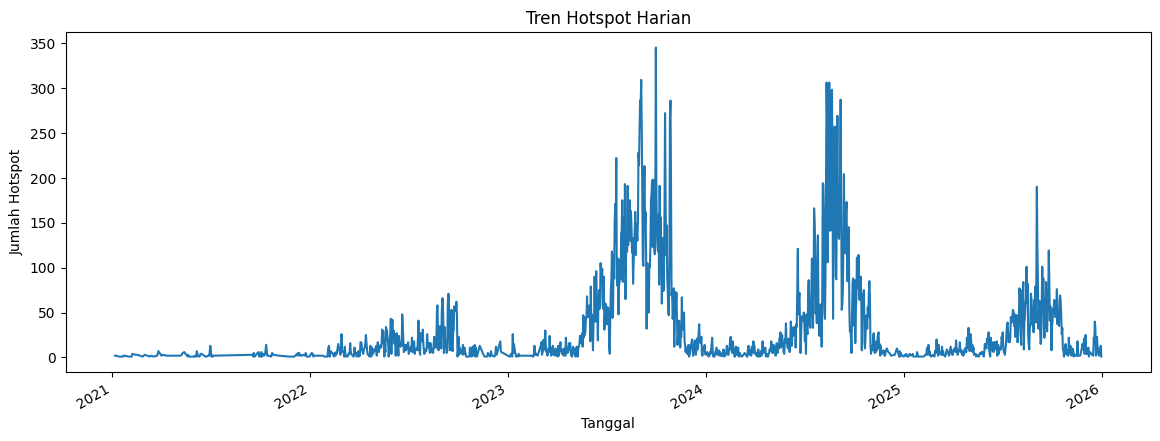

In [61]:
import matplotlib.pyplot as plt

df["Tanggal"].value_counts().sort_index().plot(figsize=(14,5))

plt.title("Tren Hotspot Harian")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Hotspot")
plt.show()

hotspot harian yang dibagi per tahun

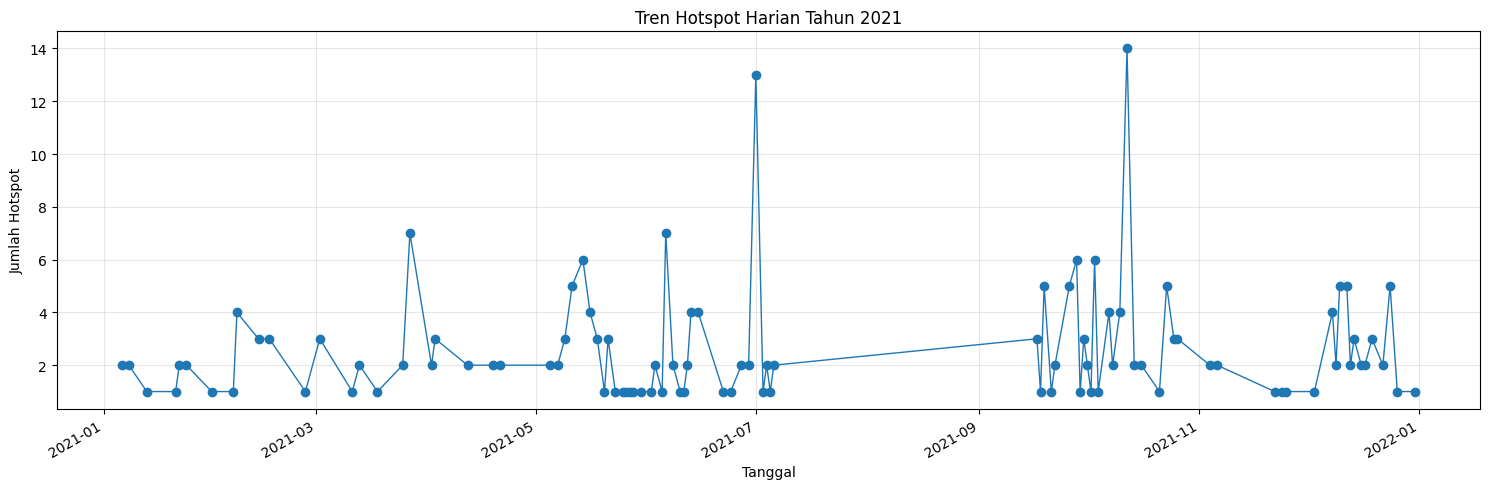

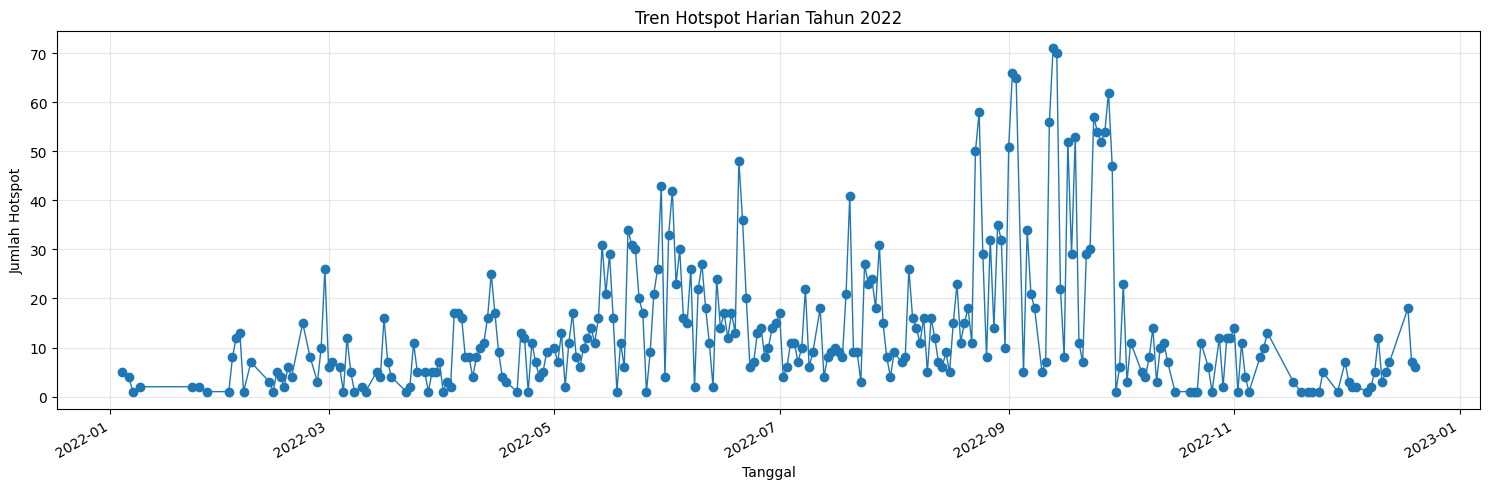

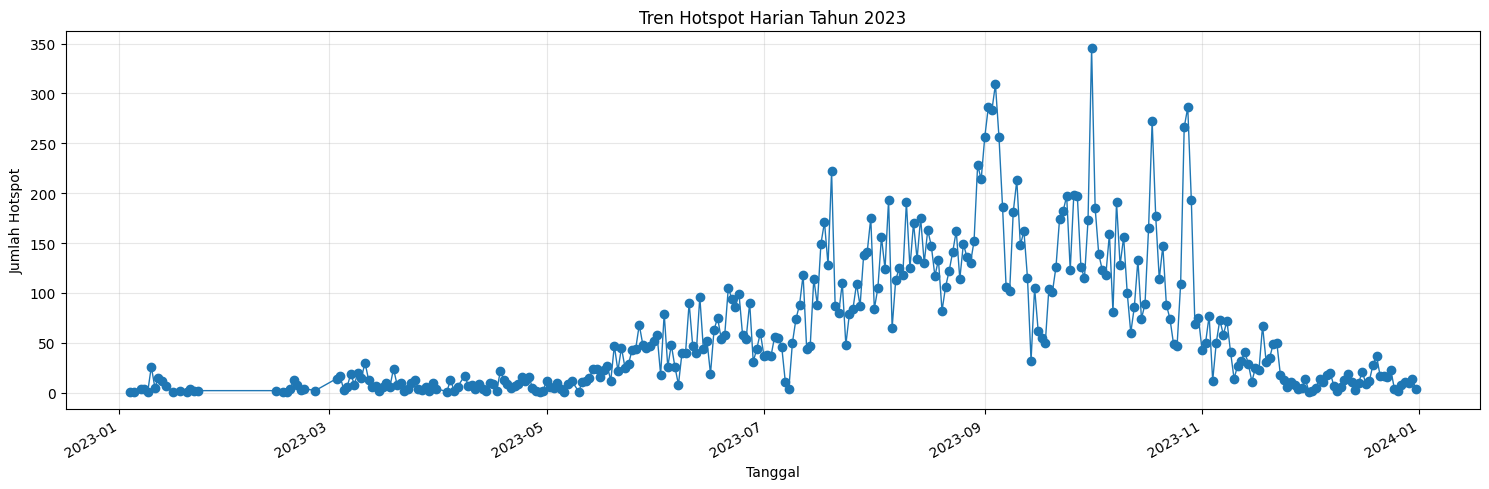

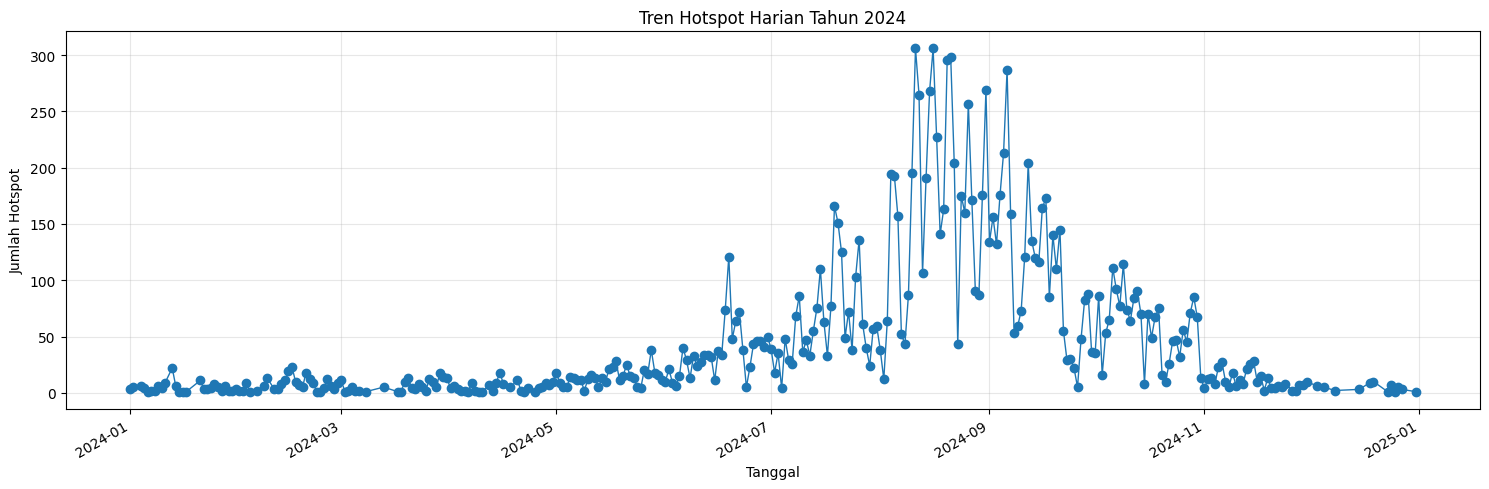

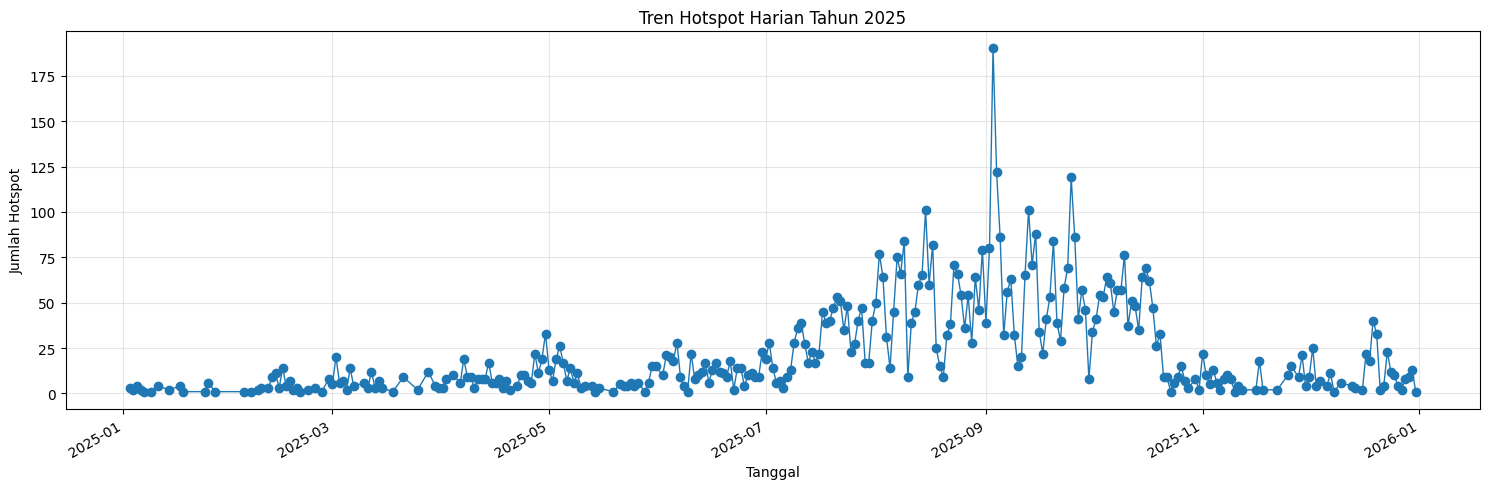

In [62]:
df["Tahun"] = df["Tanggal"].dt.year

# LOOP PLOT PER TAHUN
for tahun in sorted(df["Tahun"].dropna().unique()):

    data_tahun = df[df["Tahun"] == tahun]

    hotspot_harian = data_tahun["Tanggal"].value_counts().sort_index()

    plt.figure(figsize=(15,5))
    hotspot_harian.plot(marker="o", linewidth=1)

    plt.title(f"Tren Hotspot Harian Tahun {int(tahun)}")
    plt.xlabel("Tanggal")
    plt.ylabel("Jumlah Hotspot")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

hotspot kebakaran hutan per bulan tahun 2021-2025

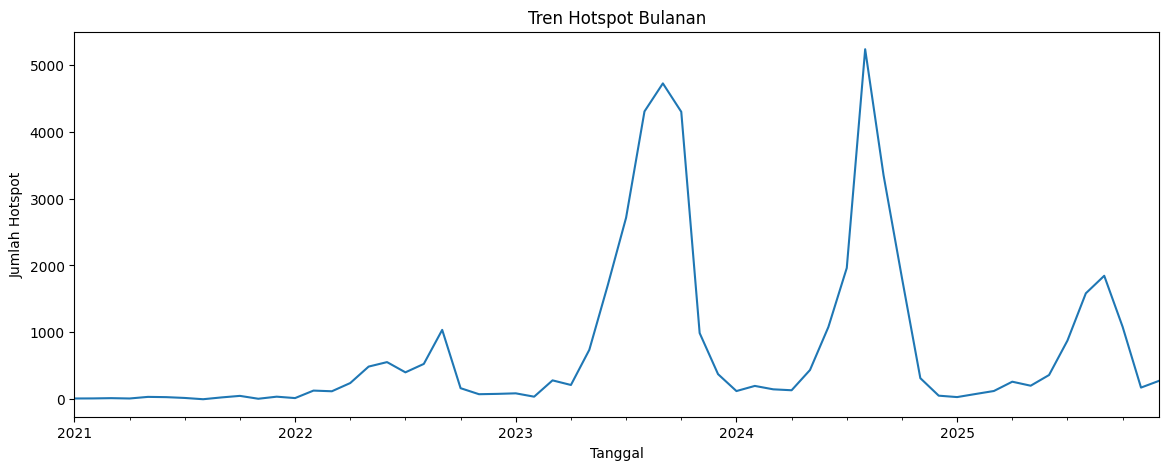

In [63]:
df.set_index("Tanggal").resample("ME").size().plot(figsize=(14,5))

plt.title("Tren Hotspot Bulanan")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Hotspot")
plt.show()

hotspot per bulan yang dibagi per tahun

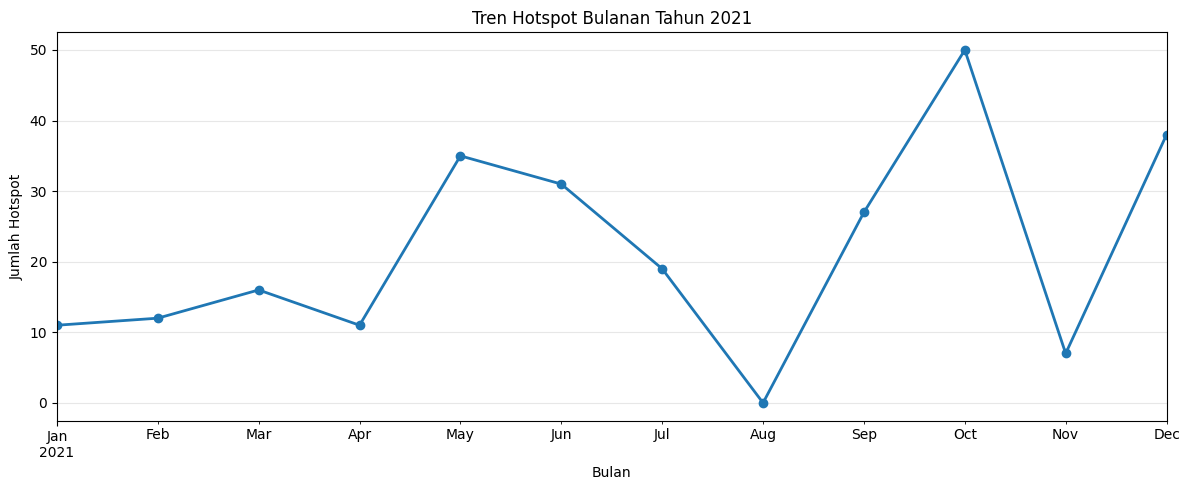

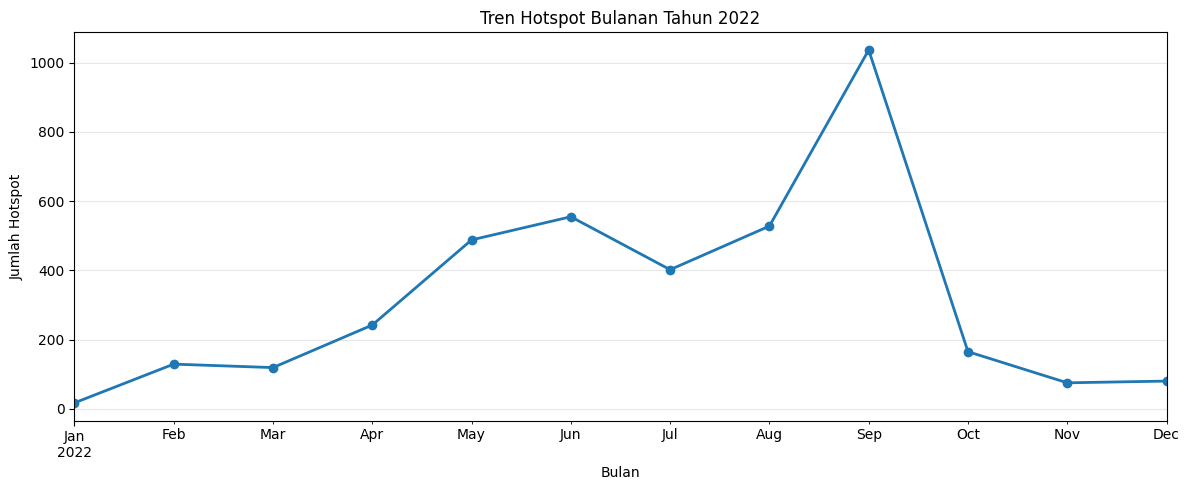

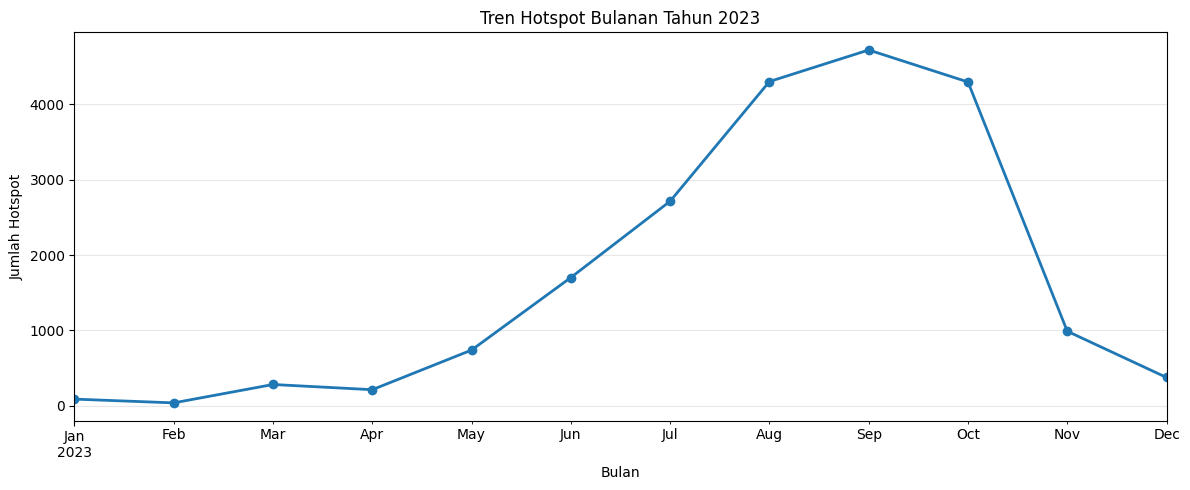

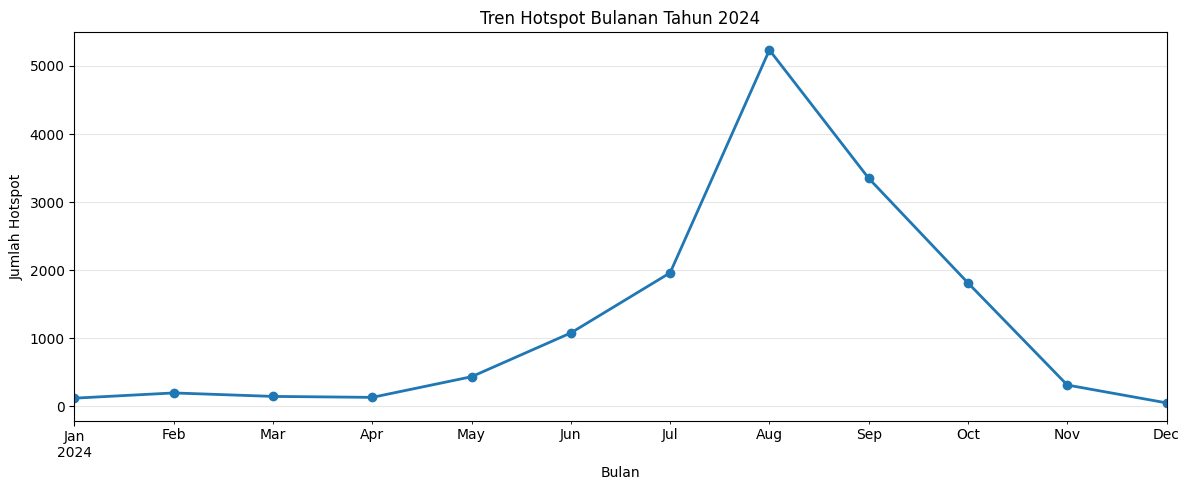

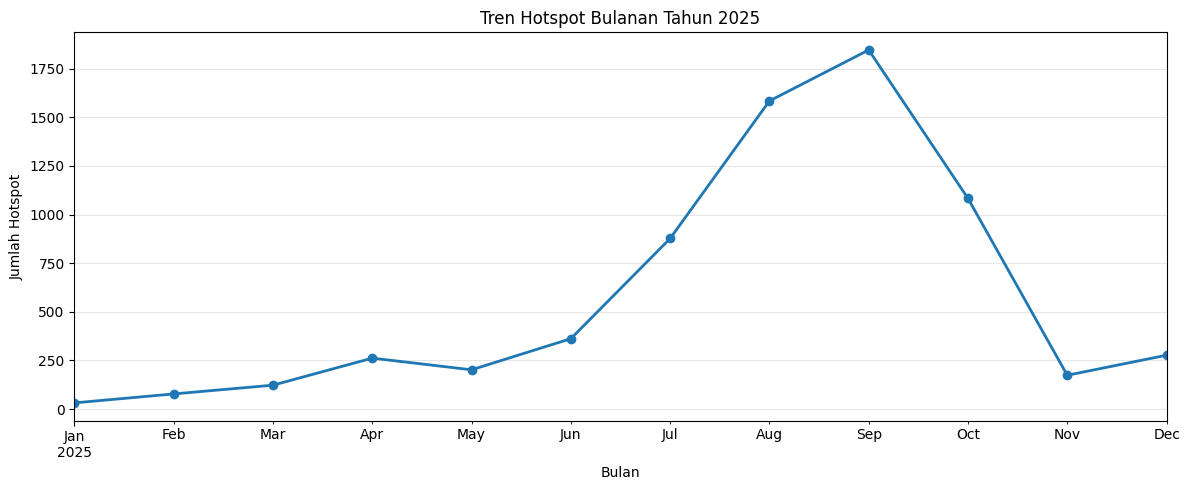

In [64]:
df["Tahun"] = df["Tanggal"].dt.year

# LOOP PLOT PER TAHUN (BULANAN)
for tahun in sorted(df["Tahun"].dropna().unique()):

    data_tahun = df[df["Tahun"] == tahun]

    hotspot_bulanan = (
        data_tahun
        .set_index("Tanggal")
        .resample("ME")
        .size()
    )

    plt.figure(figsize=(12,5))
    hotspot_bulanan.plot(marker="o", linewidth=2)

    plt.title(f"Tren Hotspot Bulanan Tahun {int(tahun)}")
    plt.xlabel("Bulan")
    plt.ylabel("Jumlah Hotspot")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

<Axes: xlabel='Tanggal'>

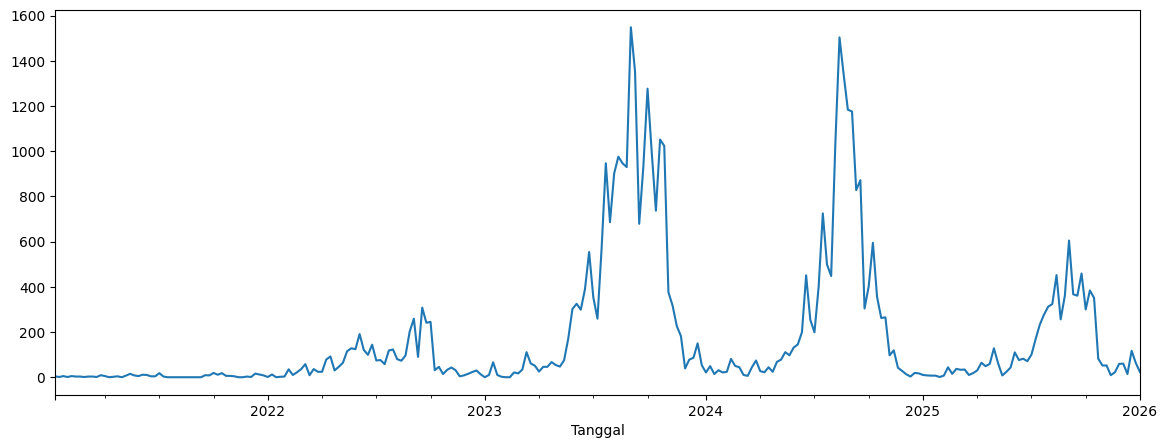

In [65]:
df.set_index("Tanggal").resample("W").size().plot(figsize=(14,5))

0    02:55:00
1    14:55:00
2    05:50:00
3    05:50:00
4    02:50:00
Name: Waktu, dtype: object


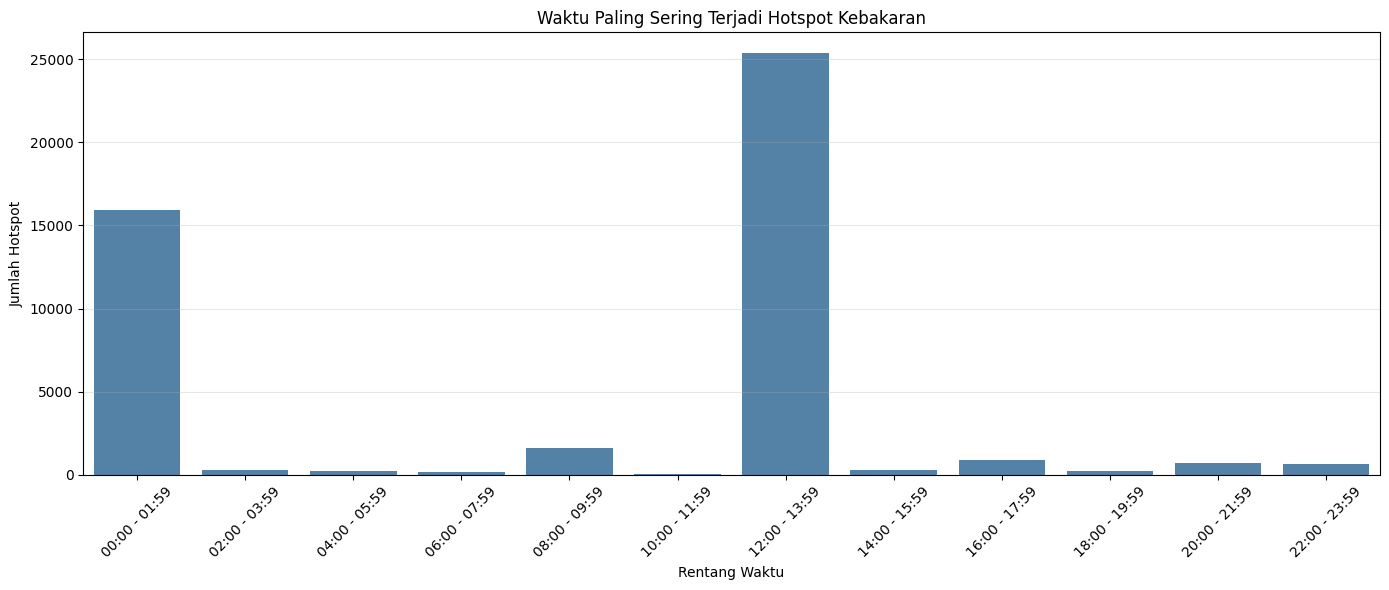

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CEK FORMAT ASLI WAKTU
print(df["Waktu"].head())

# BERSIHKAN WAKTU
df["Waktu_str"] = (
    df["Waktu"]
    .astype(str)
    .str.replace("WIB", "", regex=False)
    .str.strip()
)

# AMBIL JAM LANGSUNG (LEBIH AMAN)
df["Jam"] = df["Waktu_str"].str.split(":").str[0]

# Ubah ke angka
df["Jam"] = pd.to_numeric(df["Jam"], errors="coerce")

# Hapus null
data_jam = df.dropna(subset=["Jam"]).copy()

# RENTANG 2 JAM
data_jam["Jam_2"] = (data_jam["Jam"] // 2) * 2

data_jam["Rentang_Waktu"] = data_jam["Jam_2"].apply(
    lambda x: f"{int(x):02d}:00 - {int(x)+1:02d}:59"
)

# Urutan
urutan = [f"{i:02d}:00 - {i+1:02d}:59" for i in range(0,24,2)]

# VISUALISASI
plt.figure(figsize=(14,6))

sns.countplot(
    data=data_jam,
    x="Rentang_Waktu",
    order=urutan,
    color="steelblue"
)

plt.title("Waktu Paling Sering Terjadi Hotspot Kebakaran")
plt.xlabel("Rentang Waktu")
plt.ylabel("Jumlah Hotspot")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

jumlah kasus kebakaran 5 tahun terakhir berdasarkan kabupaten yang terdampak

In [67]:
df["Kabupaten"].value_counts()

Kabupaten
SITUBONDO       5501
MALANG          4996
LUMAJANG        4755
BOJONEGORO      3677
BONDOWOSO       2278
BANYUWANGI      1967
NGANJUK         1916
TUBAN           1871
PROBOLINGGO     1655
PASURUAN        1630
MOJOKERTO       1629
NGAWI           1475
MADIUN          1395
LAMONGAN        1271
JOMBANG         1149
JEMBER          1125
KEDIRI          1100
PONOROGO        1062
GRESIK          1000
SIDOARJO         919
SUMENEP          862
BLITAR           599
MAGETAN          590
BANGKALAN        454
 SURABAYA        250
TULUNGAGUNG      242
 BATU            201
 KEDIRI          197
SAMPANG          159
PACITAN          130
PAMEKASAN        116
TRENGGALEK        57
 MOJOKERTO        24
 PASURUAN         21
 MALANG           14
 MADIUN           13
 PROBOLINGGO       9
Name: count, dtype: int64

10 kabupaten yang yang mengalami kebakaran hutan terbanyak terhitung dari 5 tahun terakhir

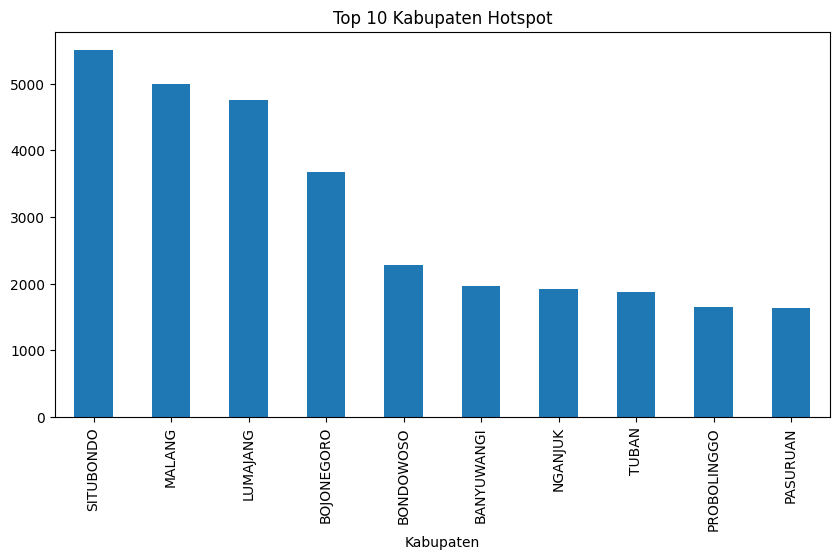

In [68]:
plt.figure(figsize=(10,5))
df["Kabupaten"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Kabupaten Hotspot")
plt.show()

jumlah kebakaran hutan dengan tingkatannya

In [69]:
df["Confidence"].value_counts()

Confidence
2    39550
1     5346
3     1413
Name: count, dtype: int64

keterangan

*   1 : low
*   2 : medium
*   3 : high

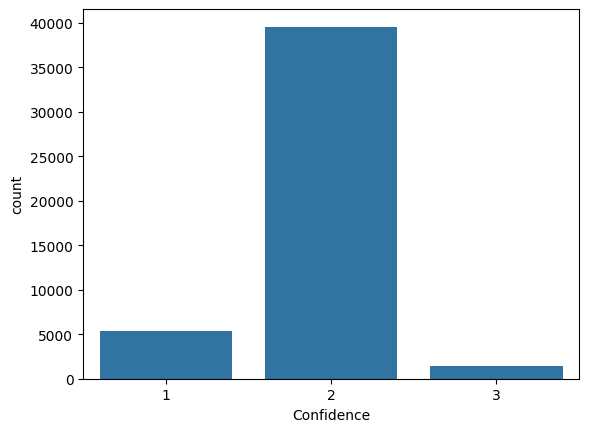

In [70]:
import seaborn as sns

sns.countplot(data=df, x="Confidence")
plt.show()

jumlah kebakaran hutan menurut fungsi lahannya

In [71]:
df["Fungsi"].value_counts()

Fungsi
APL                      37631
HP                        4991
TN                        1582
HL                        1364
Tidak Teridentifikasi      527
CA                         190
HPT                         14
TWA                         10
Name: count, dtype: int64

Jumlah Data : 46309
     Tanggal     Waktu  Latitude  Longitude     Satelit  Confidence  \
0 2021-12-31  02:55:00    -7.830    113.150  NASA-MODIS           2   
1 2021-12-26  14:55:00    -8.122    112.937  NASA-MODIS           1   
2 2021-12-24  05:50:00    -8.117    112.928  NASA-MODIS           1   
3 2021-12-24  05:50:00    -8.119    112.912  NASA-MODIS           2   
4 2021-12-24  02:50:00    -8.110    112.927  NASA-MODIS           1   

     Kabupaten              Kecamatan                   Desa Fungsi  Tahun  \
0  PROBOLINGGO  Tidak Teridentifikasi  Tidak Teridentifikasi    APL   2021   
1     LUMAJANG  Tidak Teridentifikasi  Tidak Teridentifikasi    APL   2021   
2     LUMAJANG  Tidak Teridentifikasi  Tidak Teridentifikasi    APL   2021   
3       MALANG  Tidak Teridentifikasi  Tidak Teridentifikasi    APL   2021   
4     LUMAJANG  Tidak Teridentifikasi  Tidak Teridentifikasi    APL   2021   

  Waktu_str  Jam  Bulan  
0  02:55:00    2     12  
1  14:55:00   14     12  
2  05:

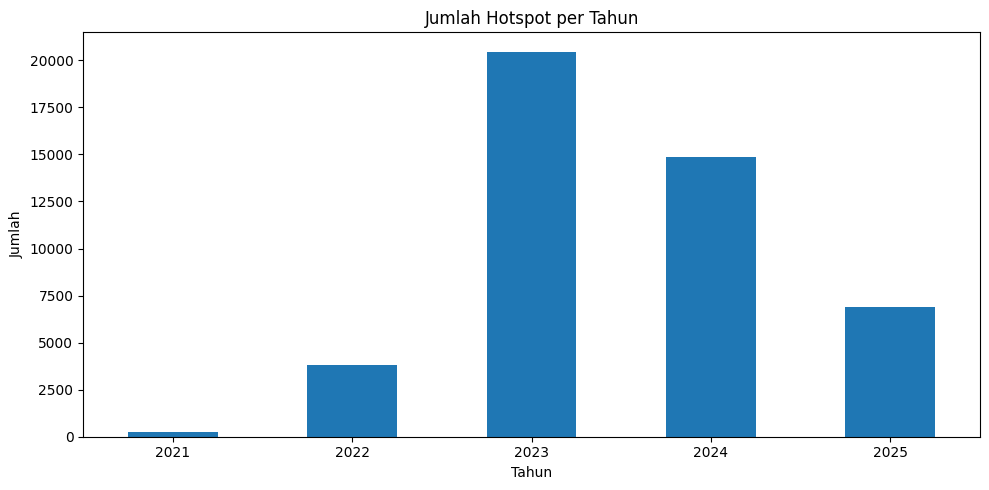

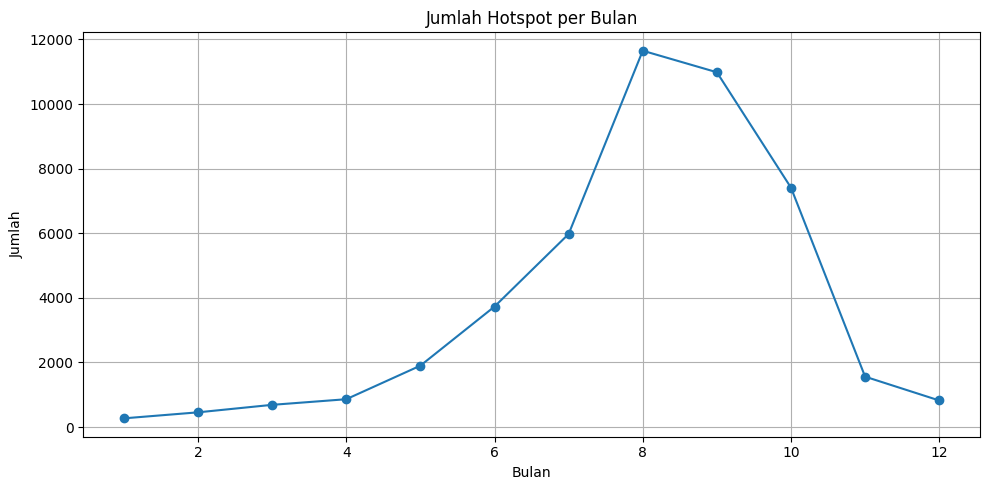

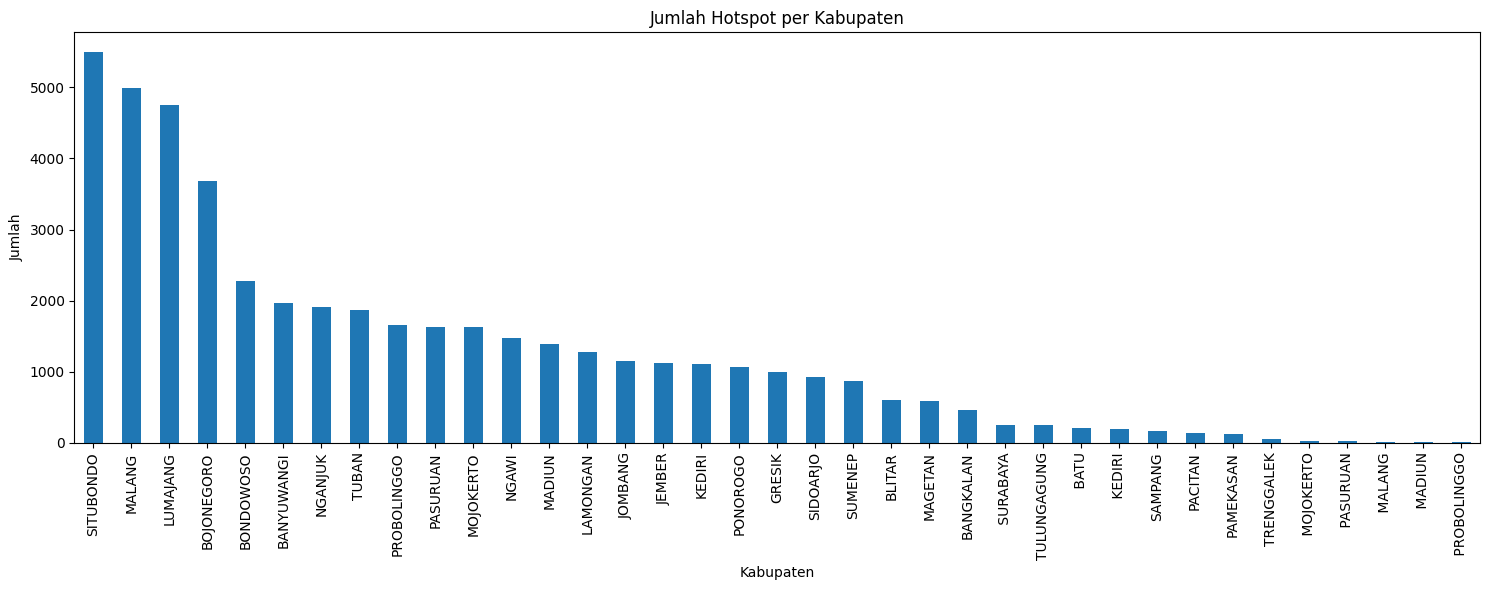

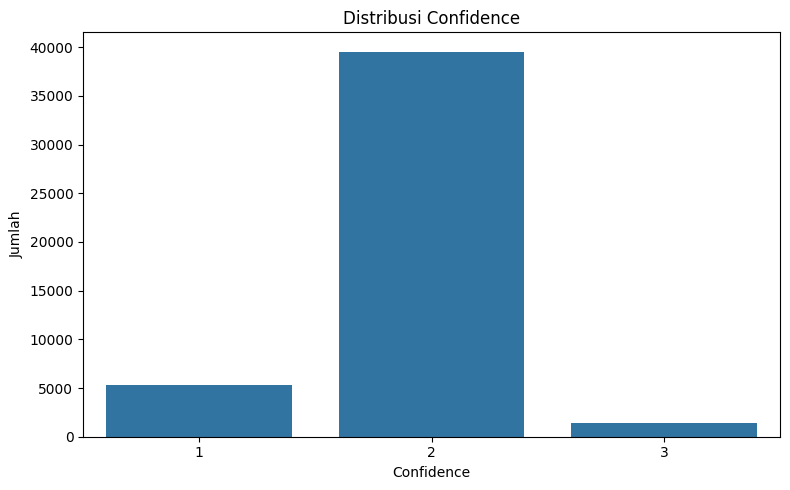

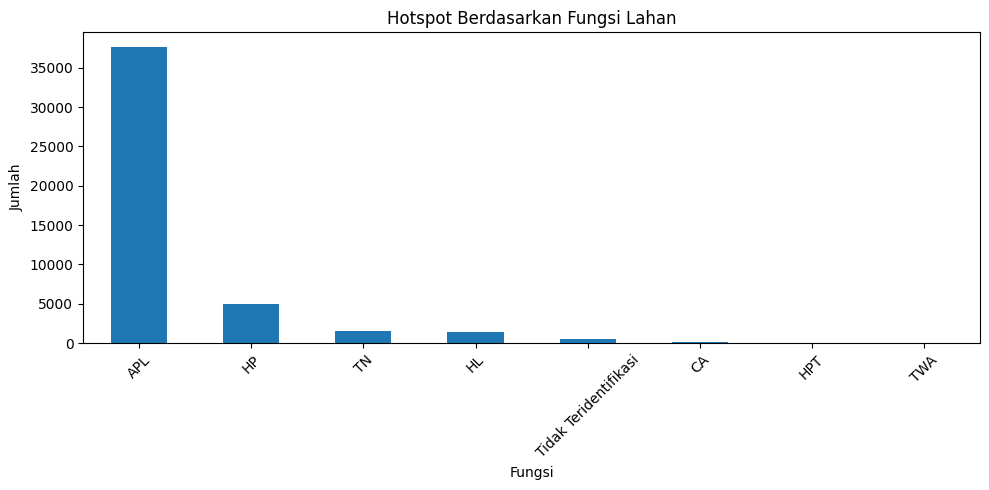

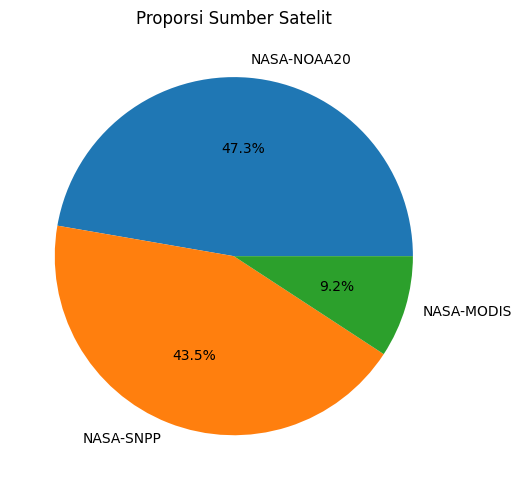


Top 10 Kabupaten dengan Hotspot Terbanyak:
Kabupaten
SITUBONDO      5501
MALANG         4996
LUMAJANG       4755
BOJONEGORO     3677
BONDOWOSO      2278
BANYUWANGI     1967
NGANJUK        1916
TUBAN          1871
PROBOLINGGO    1655
PASURUAN       1630
Name: count, dtype: int64

Confidence:
Confidence
2    39550
1     5346
3     1413
Name: count, dtype: int64

Fungsi Lahan:
Fungsi
APL                      37631
HP                        4991
TN                        1582
HL                        1364
Tidak Teridentifikasi      527
CA                         190
HPT                         14
TWA                         10
Name: count, dtype: int64

Satelit:
Satelit
NASA-NOAA20    21892
NASA-SNPP      20151
NASA-MODIS      4266
Name: count, dtype: int64


In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil Tahun dan Bulan
df["Tahun"] = df["Tanggal"].dt.year
df["Bulan"] = df["Tanggal"].dt.month

# INFO DATA
print("Jumlah Data :", len(df))
print(df.head())
print(df.info())

# 1. HOTSPOT PER TAHUN
plt.figure(figsize=(10,5))
df["Tahun"].value_counts().sort_index().plot(kind="bar")
plt.title("Jumlah Hotspot per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. HOTSPOT PER BULAN
plt.figure(figsize=(10,5))
df["Bulan"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Jumlah Hotspot per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. KABUPATEN DENGAN HOTSPOT TERBANYAK
plt.figure(figsize=(15,6))
df["Kabupaten"].value_counts().plot(kind="bar")
plt.title("Jumlah Hotspot per Kabupaten")
plt.xlabel("Kabupaten")
plt.ylabel("Jumlah")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 4. CONFIDENCE
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Confidence")
plt.title("Distribusi Confidence")
plt.xlabel("Confidence")
plt.ylabel("Jumlah")
plt.tight_layout()
plt.show()

# 5. FUNGSI LAHAN
plt.figure(figsize=(10,5))
df["Fungsi"].value_counts().plot(kind="bar")
plt.title("Hotspot Berdasarkan Fungsi Lahan")
plt.xlabel("Fungsi")
plt.ylabel("Jumlah")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. SATELIT
plt.figure(figsize=(8,5))
df["Satelit"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Proporsi Sumber Satelit")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 7. TOP 10 KABUPATEN
print("\nTop 10 Kabupaten dengan Hotspot Terbanyak:")
print(df["Kabupaten"].value_counts().head(10))

# 8. RINGKASAN DATA
print("\nConfidence:")
print(df["Confidence"].value_counts())

print("\nFungsi Lahan:")
print(df["Fungsi"].value_counts())

print("\nSatelit:")
print(df["Satelit"].value_counts())

sebaran hotspot dengan titik tingkatannya

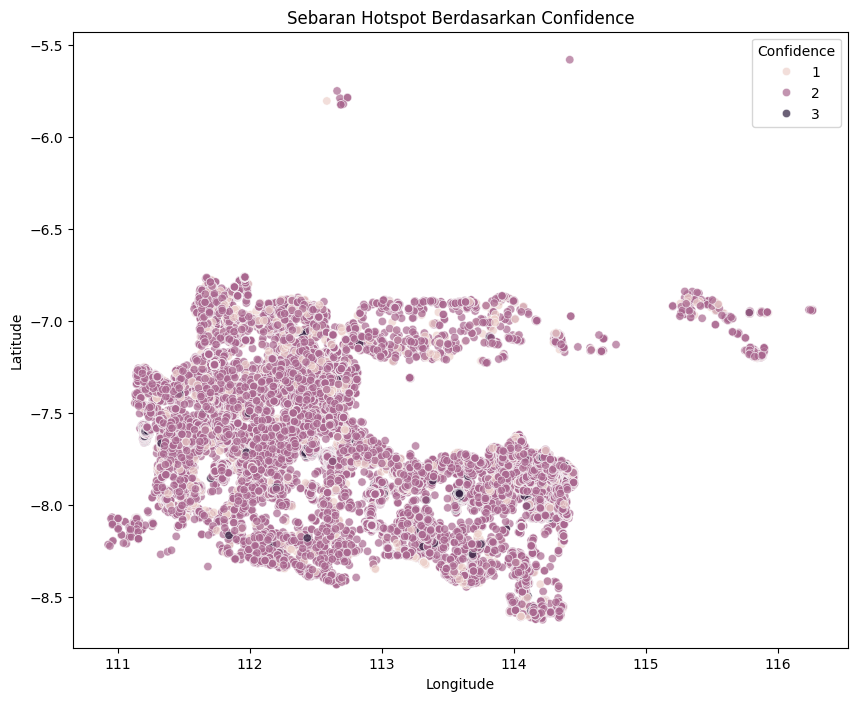

In [73]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="Confidence",
    alpha=0.7
)

plt.title("Sebaran Hotspot Berdasarkan Confidence")
plt.show()

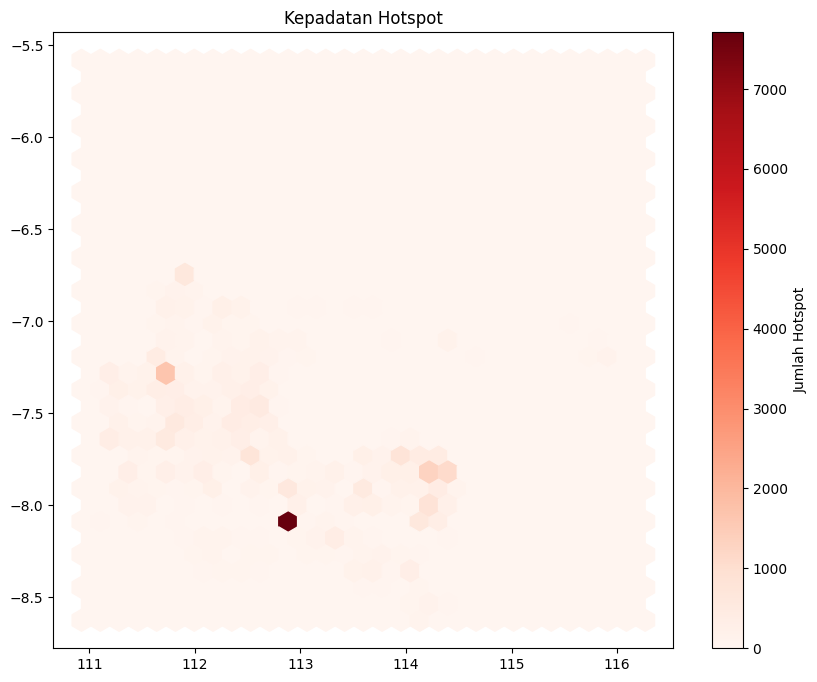

In [74]:
plt.figure(figsize=(10,8))

plt.hexbin(
    df["Longitude"],
    df["Latitude"],
    gridsize=30,
    cmap="Reds"
)

plt.colorbar(label="Jumlah Hotspot")
plt.title("Kepadatan Hotspot")
plt.show()

# Clustering

       Kabupaten  Total_Risk Kategori
19        MADIUN    6.632258   Sedang
23       NGANJUK    6.599165   Sedang
32     SITUBONDO    6.576441   Sedang
24         NGAWI    6.559322   Sedang
18      LUMAJANG    6.558991   Sedang
27      PASURUAN    6.558282   Sedang
35         TUBAN    6.542491   Sedang
17      LAMONGAN    6.522423   Sedang
11    BOJONEGORO    6.513190   Sedang
15       JOMBANG    6.507398   Sedang
28      PONOROGO    6.451036   Sedang
21        MALANG    6.425741   Sedang
9     BANYUWANGI    6.324352   Sedang
13        GRESIK    6.264000   Sedang
16        KEDIRI    6.244545   Sedang
22     MOJOKERTO    6.213628   Sedang
14        JEMBER    6.208000   Sedang
29   PROBOLINGGO    6.143807   Sedang
12     BONDOWOSO    6.140035   Sedang
6    PROBOLINGGO    4.777778   Rendah
8      BANGKALAN    4.660793   Rendah
4      MOJOKERTO    4.625000   Rendah
26     PAMEKASAN    4.551724   Rendah
5       PASURUAN    4.476190   Rendah
30       SAMPANG    4.452830   Rendah
0           

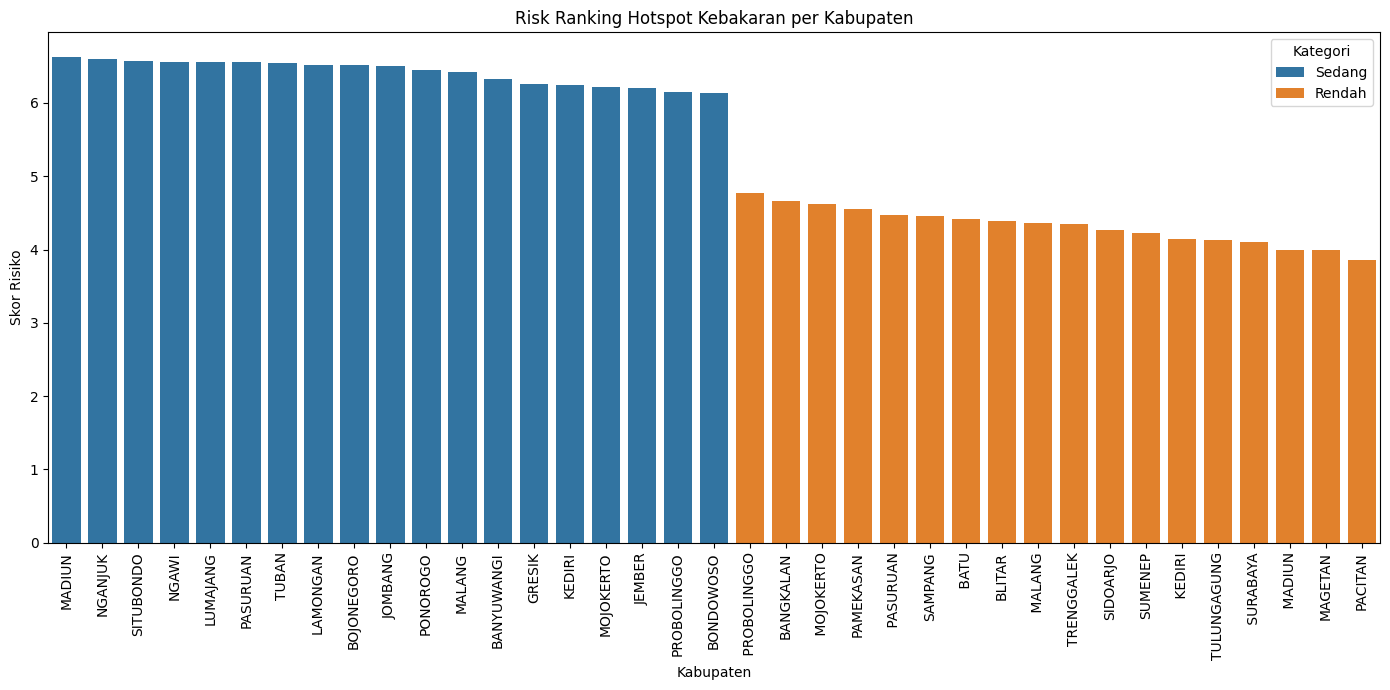

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil bulan
df["Bulan"] = df["Tanggal"].dt.month

# SKOR CONFIDENCE
df["Skor_Confidence"] = df["Confidence"]

# BULAN KEMARAU (contoh: April - September)
bulan_kemarau = [4,5,6,7,8,9]

df["Skor_Kemarau"] = np.where(df["Bulan"].isin(bulan_kemarau), 2, 0)

# HITUNG JUMLAH HOTSPOT PER KABUPATEN
jumlah_hotspot = df["Kabupaten"].value_counts()

# Threshold historis tinggi = median
batas_hotspot = jumlah_hotspot.median()

df["Jumlah_Historis"] = df["Kabupaten"].map(jumlah_hotspot)

df["Skor_Historis"] = np.where(
    df["Jumlah_Historis"] >= batas_hotspot,
    3,
    1
)

# TOTAL SKOR RISIKO
df["Total_Risk"] = (
    df["Skor_Historis"] +
    df["Skor_Confidence"] +
    df["Skor_Kemarau"]
)

# RATA-RATA RISIKO PER KABUPATEN
risk_rank = (
    df.groupby("Kabupaten")["Total_Risk"]
    .mean()
    .reset_index()
)

# KATEGORI RISIKO
def kategori(nilai):
    if nilai >= 7:
        return "Tinggi"
    elif nilai >= 5:
        return "Sedang"
    else:
        return "Rendah"

risk_rank["Kategori"] = risk_rank["Total_Risk"].apply(kategori)

# Urutkan tertinggi
risk_rank = risk_rank.sort_values("Total_Risk", ascending=False)

# TAMPILKAN HASIL
print(risk_rank)

# VISUALISASI
plt.figure(figsize=(14,7))

sns.barplot(
    data=risk_rank,
    x="Kabupaten",
    y="Total_Risk",
    hue="Kategori",
    dodge=False
)

plt.title("Risk Ranking Hotspot Kebakaran per Kabupaten")
plt.xlabel("Kabupaten")
plt.ylabel("Skor Risiko")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

    Kabupaten  Jumlah_Hotspot  Rata_Confidence  Latitude   Longitude
0        BATU             201         2.029851 -7.760828  112.565655
1      KEDIRI             197         1.756345 -7.811082  112.015134
2      MADIUN              13         1.769231 -7.635756  111.520340
3      MALANG              14         1.785714 -7.988069  112.633664
4   MOJOKERTO              24         1.958333 -7.467231  112.447912


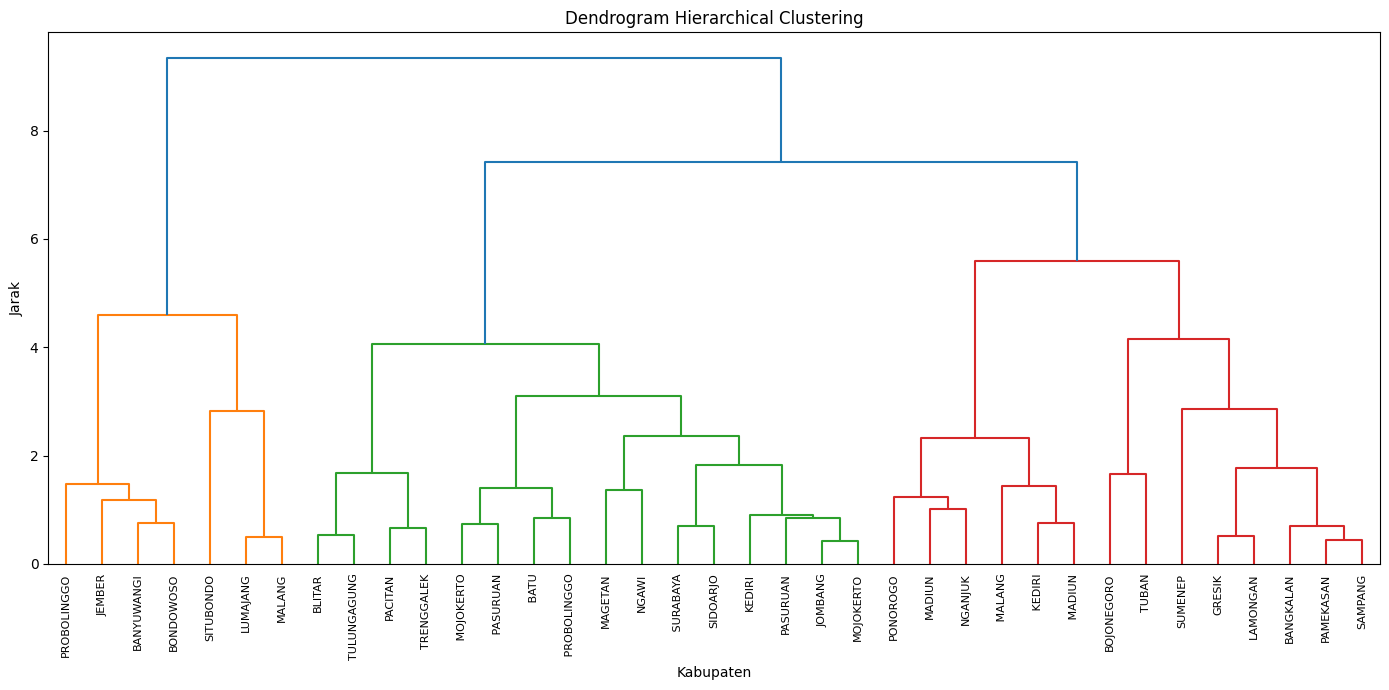

       Kabupaten  Jumlah_Hotspot  Rata_Confidence  Latitude   Longitude  \
0           BATU             201         2.029851 -7.760828  112.565655   
1         KEDIRI             197         1.756345 -7.811082  112.015134   
2         MADIUN              13         1.769231 -7.635756  111.520340   
3         MALANG              14         1.785714 -7.988069  112.633664   
4      MOJOKERTO              24         1.958333 -7.467231  112.447912   
5       PASURUAN              21         1.952381 -7.659688  112.902724   
6    PROBOLINGGO               9         2.000000 -7.758909  113.215316   
7       SURABAYA             250         1.900000 -7.266057  112.688722   
8      BANGKALAN             454         1.810573 -7.086733  112.913830   
9     BANYUWANGI            1967         1.920183 -8.215602  114.214479   
10        BLITAR             599         1.881469 -8.208066  112.200351   
11    BOJONEGORO            3677         1.878162 -7.269142  111.735496   
12     BONDOWOSO         

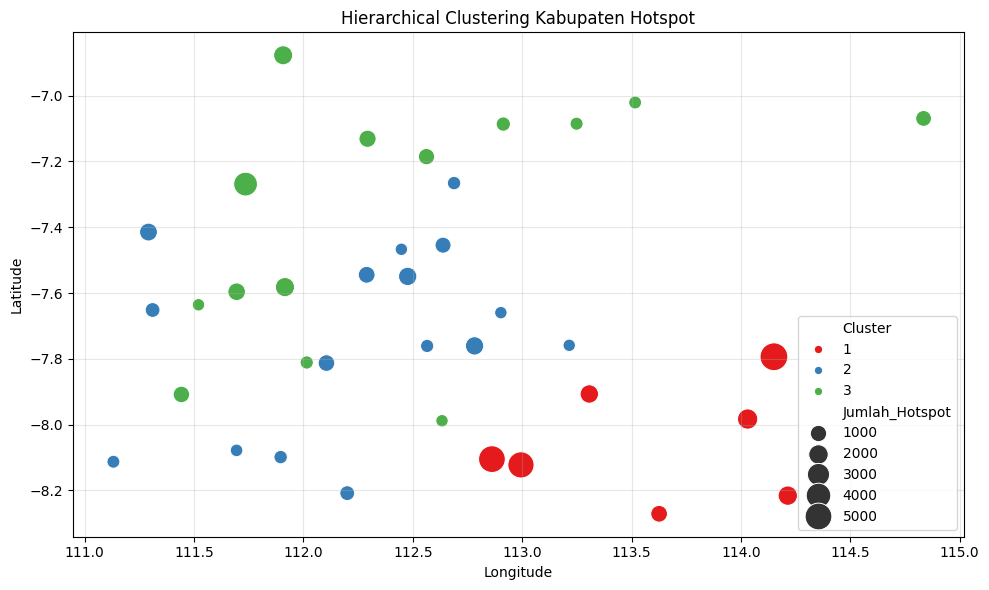

In [76]:
# HIERARCHICAL CLUSTERING HOTSPOT KABUPATEN

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
# 1. RAPIIKAN DATA

# Confidence sudah numerik
df["Conf_Num"] = pd.to_numeric(df["Confidence"], errors="coerce")

# Latitude Longitude
df["Latitude"] = (
    df["Latitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df["Longitude"] = (
    df["Longitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# 2. RINGKAS PER KABUPATEN
cluster_df = df.groupby("Kabupaten").agg(
    Jumlah_Hotspot=("Kabupaten","size"),
    Rata_Confidence=("Conf_Num","mean"),
    Latitude=("Latitude","mean"),
    Longitude=("Longitude","mean")
).reset_index()

print(cluster_df.head())

# 3. FITUR
X = cluster_df[
    ["Jumlah_Hotspot", "Rata_Confidence", "Latitude", "Longitude"]
]

# 4. NORMALISASI
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. LINKAGE MATRIX
Z = linkage(X_scaled, method="ward")

# 6. DENDROGRAM
plt.figure(figsize=(14,7))

dendrogram(
    Z,
    labels=cluster_df["Kabupaten"].values,
    leaf_rotation=90
)

plt.title("Dendrogram Hierarchical Clustering")
plt.xlabel("Kabupaten")
plt.ylabel("Jarak")
plt.tight_layout()
plt.show()

# 7. POTONG JADI 3 CLUSTER
cluster_df["Cluster"] = fcluster(
    Z,
    t=3,
    criterion="maxclust"
)

# 8. HASIL
print(cluster_df)

# 9. VISUALISASI PETA SCATTER
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=cluster_df,
    x="Longitude",
    y="Latitude",
    hue="Cluster",
    size="Jumlah_Hotspot",
    sizes=(80,400),
    palette="Set1"
)

plt.title("Hierarchical Clustering Kabupaten Hotspot")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Peta interaktif

In [77]:
# %pip install folium

In [78]:
# import pandas as pd
# import folium
# from folium.plugins import HeatMap, Fullscreen, MiniMap, MeasureControl, MousePosition

# df = pd.read_csv("Data Kebakaran 5 Tahun Terakhir.csv", sep=",")

# df.columns = df.columns.str.strip()

# df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")

# df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")


# df = df.dropna(subset=["Latitude", "Longitude"])

# def warna(conf):
#     conf = str(conf)
#     if conf == "3":
#         return "red"
#     elif conf == "2":
#         return "orange"
#     else:
#         return "yellow"

# m = folium.Map(location=[-7.7, 112.8], zoom_start=8, tiles="OpenStreetMap")
# folium.TileLayer("OpenStreetMap", name="Street").add_to(m)
# folium.TileLayer("CartoDB positron", name="Light").add_to(m)
# folium.TileLayer("CartoDB dark_matter", name="Dark").add_to(m)
# Fullscreen().add_to(m)
# MiniMap(toggle_display=True).add_to(m)
# MeasureControl().add_to(m)
# MousePosition().add_to(m)

# for _, row in df.iterrows():
#     folium.CircleMarker(
#         location=[row["Latitude"], row["Longitude"]],
#         radius=5,
#         color=warna(row["Confidence"]),
#         fill=True,
#         fill_color=warna(row["Confidence"]),
#         fill_opacity=0.75,
#         popup=f"""<b>Kabupaten:</b> {row['Kabupaten']}<br>
# <b>Tanggal:</b> {row['Tanggal']}<br>
# <b>Confidence:</b> {row['Confidence']}
#         """,
#         tooltip=row["Kabupaten"]
#     ).add_to(m)

# HeatMap(df[["Latitude","Longitude"]].values.tolist(), radius=18, blur=15).add_to(m)
# folium.LayerControl().add_to(m)

# title_html = """
# <h3 align="center" style="font-size:20px">
# <b>Peta Interaktif Hotspot Kebakaran Jawa Timur</b>
# </h3>
# """
# m.get_root().html.add_child(folium.Element(title_html))

# m.save("peta_hotspot_alahle.html")
# print("Peta berhasil dibuat")


# Model

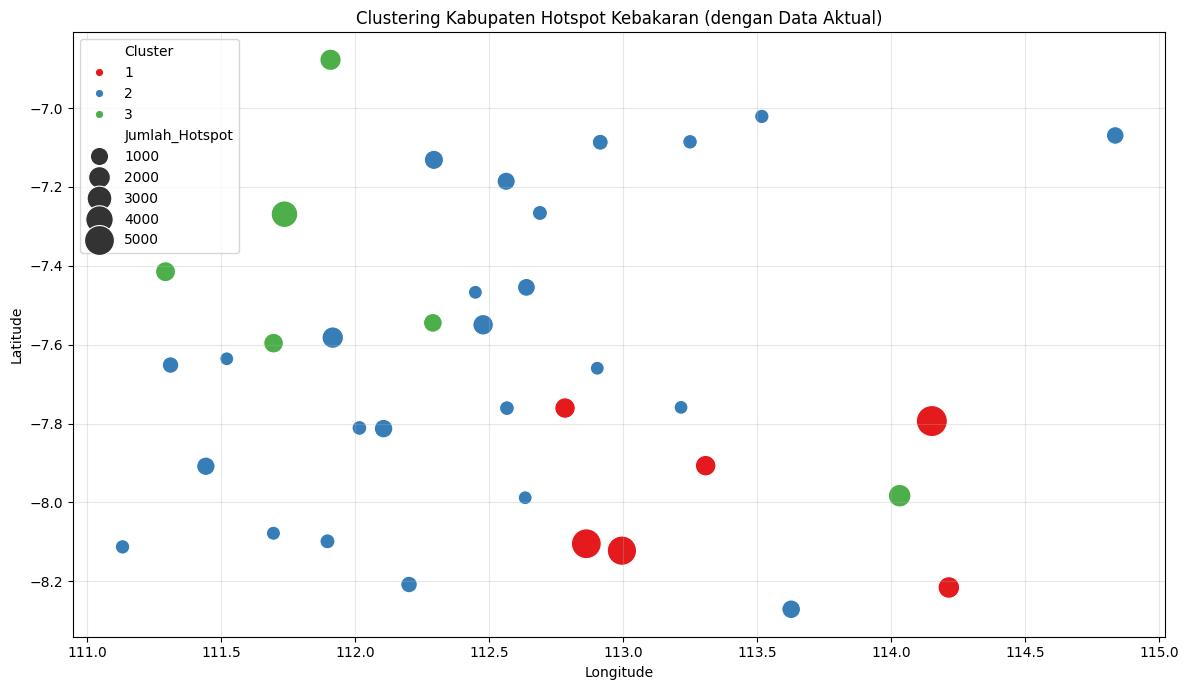

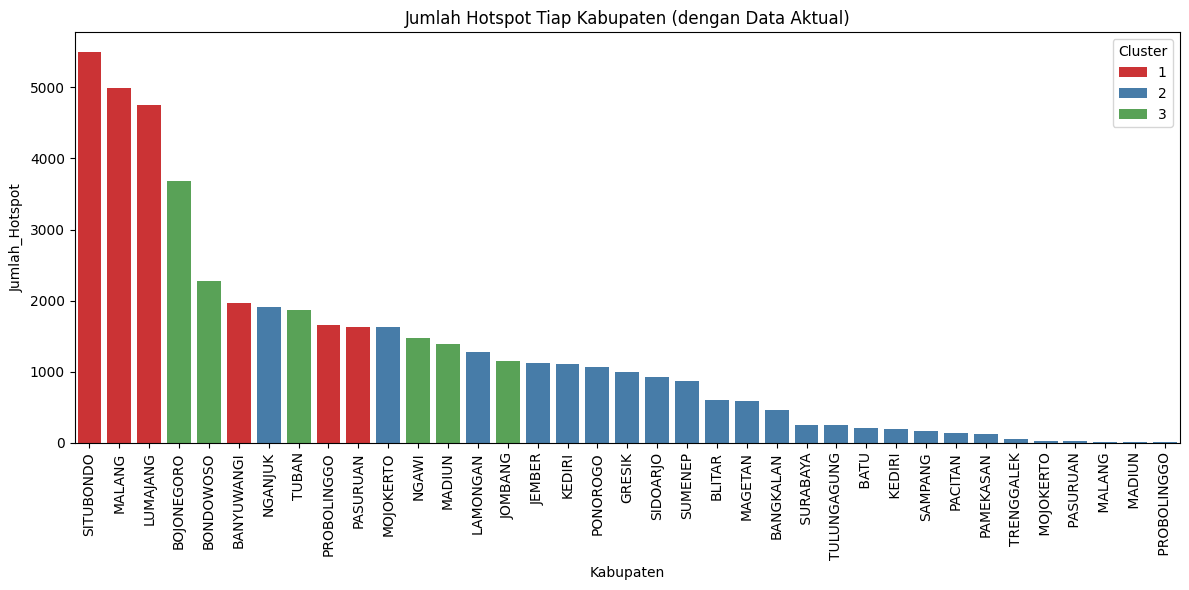

Berhasil disimpan:
model_kmeans_hotspot.pkl
scaler_hotspot.pkl
hasil_cluster_hotspot.csv


In [79]:

# TRAIN MODEL + VISUALISASI + SIMPAN MODEL (dengan data aktual)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load merged data (hotspot + aktual)
df_merged = pd.read_csv("data_hotspot_dan_aktual.csv")

# FITUR: hotspot features + actual fire features
fitur = [
    "Jumlah_Hotspot",
    "Rata_Confidence",
    "Latitude",
    "Longitude",
    "Total_Luas_Ha",
    "Jumlah_Kejadian",
    "Rata_Luas_Ha"
]

X = df_merged[fitur]

# SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMEANS
model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_merged["Cluster"] = model.fit_predict(X_scaled) + 1

# VISUALISASI CLUSTER
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df_merged,
    x="Longitude",
    y="Latitude",
    hue="Cluster",
    size="Jumlah_Hotspot",
    sizes=(100,500),
    palette="Set1"
)

plt.title("Clustering Kabupaten Hotspot Kebakaran (dengan Data Aktual)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# BARPLOT HOTSPOT PER CLUSTER
plt.figure(figsize=(12,6))

sns.barplot(
    data=df_merged.sort_values("Jumlah_Hotspot", ascending=False),
    x="Kabupaten",
    y="Jumlah_Hotspot",
    hue="Cluster",
    dodge=False,
    palette="Set1"
)

plt.title("Jumlah Hotspot Tiap Kabupaten (dengan Data Aktual)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# SIMPAN MODEL
joblib.dump(model, "model_kmeans_hotspot.pkl")
joblib.dump(scaler, "scaler_hotspot.pkl")

# SIMPAN HASIL CLUSTER (dengan data aktual)
df_merged.to_csv(
    "hasil_cluster_hotspot.csv",
    index=False
)

print("Berhasil disimpan:")
print("model_kmeans_hotspot.pkl")
print("scaler_hotspot.pkl")
print("hasil_cluster_hotspot.csv")


# Time Series Forecasting Hotspot

Data bulanan:
            Jumlah_Hotspot
Tanggal                   
2021-01-31              11
2021-02-28              12
2021-03-31              16
2021-04-30              11
2021-05-31              35
Total bulan: 60


C:\Users\danisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\danisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\danisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


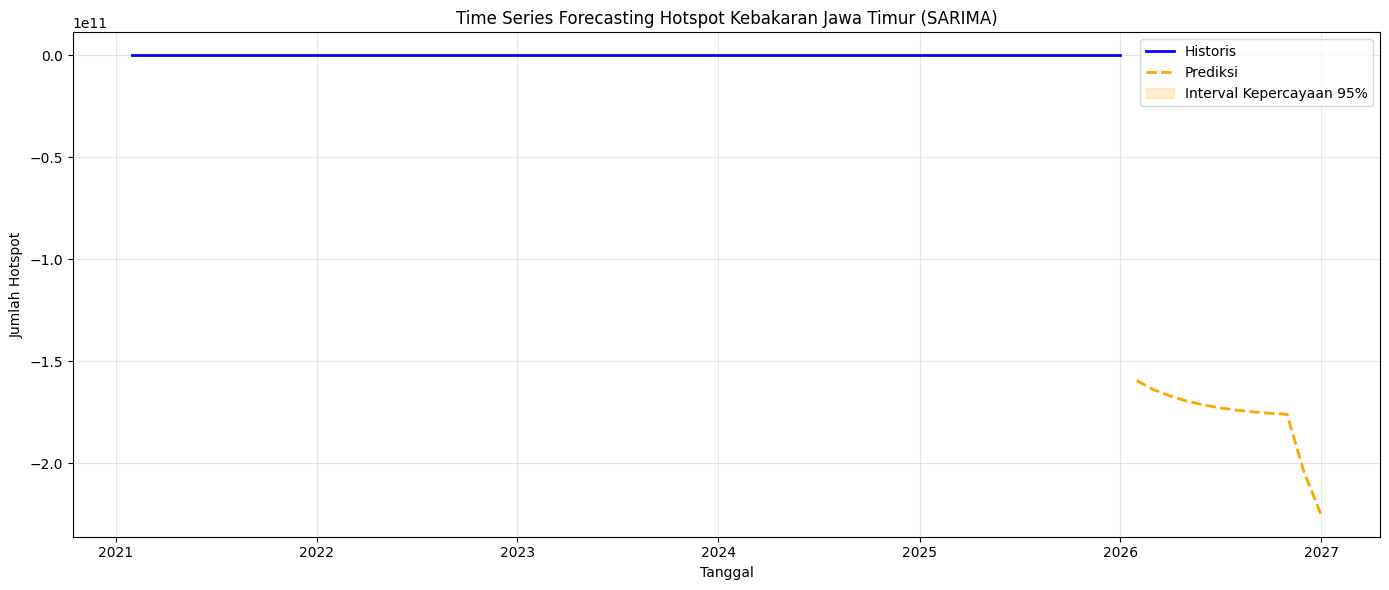


Forecast 12 bulan ke depan:
   Tanggal      Prediksi  CI_Bawah  CI_Atas
2026-01-31 -1.594471e+11       NaN      NaN
2026-02-28 -1.636672e+11       NaN      NaN
2026-03-31 -1.669140e+11       NaN      NaN
2026-04-30 -1.694120e+11       NaN      NaN
2026-05-31 -1.713339e+11       NaN      NaN
2026-06-30 -1.728125e+11       NaN      NaN
2026-07-31 -1.739501e+11       NaN      NaN
2026-08-31 -1.748253e+11       NaN      NaN
2026-09-30 -1.754987e+11       NaN      NaN
2026-10-31 -1.760167e+11       NaN      NaN
2026-11-30 -2.035823e+11       NaN      NaN
2026-12-31 -2.247903e+11       NaN      NaN


In [80]:
# TIME SERIES FORECASTING HOTSPOT (SARIMA)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

# Load hotspot data
df = pd.read_csv("Data Kebakaran 5 Tahun Terakhir.csv", sep=",")
df["Tanggal"] = pd.to_datetime(df["Tanggal"], errors="coerce")

# Aggregate monthly
df_bulanan = df.set_index("Tanggal").resample("ME").size().reset_index(name="Jumlah_Hotspot")
df_bulanan = df_bulanan[df_bulanan["Tanggal"] >= "2021-01-01"]
df_bulanan = df_bulanan.set_index("Tanggal")

print("Data bulanan:")
print(df_bulanan.head())
print(f"Total bulan: {len(df_bulanan)}")

# Fit SARIMA model
model = SARIMAX(
    df_bulanan["Jumlah_Hotspot"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
result = model.fit(disp=False)

# Forecast 12 months
forecast = result.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Combine historical + forecast
last_date = df_bulanan.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq="ME")

# Save forecast data for Streamlit
df_forecast = pd.DataFrame({
    "Tanggal": forecast_index,
    "Prediksi": forecast_mean.values,
    "CI_Bawah": forecast_ci.iloc[:, 0].values,
    "CI_Atas": forecast_ci.iloc[:, 1].values
})
df_forecast.to_csv("forecast_hotspot.csv", index=False)

# Save historical data
df_hist = df_bulanan.reset_index()
df_hist.columns = ["Tanggal", "Jumlah_Hotspot"]
df_hist.to_csv("histori_hotspot.csv", index=False)

# Plot
plt.figure(figsize=(14, 6))

plt.plot(df_bulanan.index, df_bulanan["Jumlah_Hotspot"], label="Historis", color="blue", linewidth=2)
plt.plot(forecast_index, forecast_mean, label="Prediksi", color="orange", linestyle="--", linewidth=2)
plt.fill_between(forecast_index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                 color="orange", alpha=0.2, label="Interval Kepercayaan 95%")

plt.title("Time Series Forecasting Hotspot Kebakaran Jawa Timur (SARIMA)")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Hotspot")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nForecast 12 bulan ke depan:")
print(df_forecast.to_string(index=False))


# Anomali Detection Hotspot

Total data bulan-kabupaten: 1218
Total anomali terdeteksi: 27

Daftar anomali:
  Kabupaten  Tahun  Bulan  Jumlah_Hotspot  Z_Score
     KEDIRI   2024      8              23 3.711868
 BANYUWANGI   2024      8             289 3.485320
     BLITAR   2024      8             100 3.130951
 BOJONEGORO   2024      8             613 4.423530
  BONDOWOSO   2023      9             355 3.135896
  BONDOWOSO   2023     10             457 4.194959
     GRESIK   2024      8             140 3.863306
     JEMBER   2023     10             195 3.993384
    JOMBANG   2024      8             151 3.183787
     KEDIRI   2024     10             124 3.144551
   LAMONGAN   2024      8             242 3.709097
   LAMONGAN   2024      9             208 3.111422
   LUMAJANG   2023      6             587 4.403829
   LUMAJANG   2023      7             445 3.168965
     MADIUN   2024      8             338 3.715235
    MAGETAN   2023     10             261 4.544911
     MALANG   2023      9             360 3.173402
  M

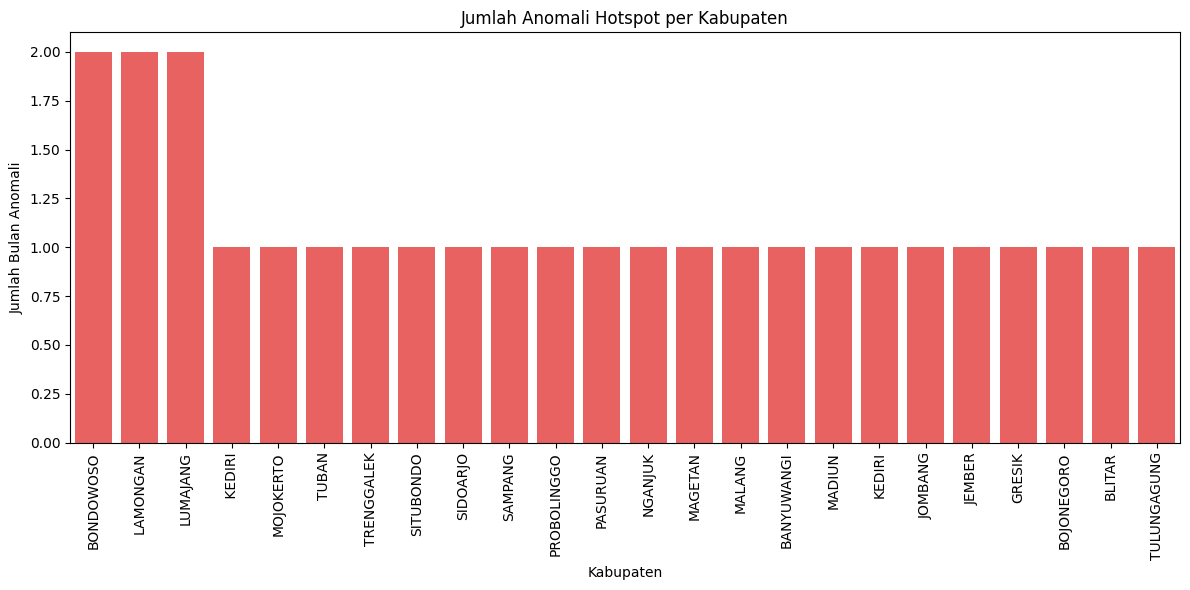

In [81]:
# ANOMALI DETECTION HOTSPOT PER KABUPATEN

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv("Data Kebakaran 5 Tahun Terakhir.csv", sep=",")
df["Tanggal"] = pd.to_datetime(df["Tanggal"], errors="coerce")
df["Tahun"] = df["Tanggal"].dt.year
df["Bulan"] = df["Tanggal"].dt.month

# Aggregate per kabupaten per bulan
df_bulanan_kab = df.groupby(["Kabupaten", "Tahun", "Bulan"]).size().reset_index(name="Jumlah_Hotspot")

# Anomali detection: Z-score method per kabupaten
def deteksi_anomali(group):
    mean = group["Jumlah_Hotspot"].mean()
    std = group["Jumlah_Hotspot"].std()
    if std == 0:
        group["Anomali"] = False
        group["Z_Score"] = 0.0
    else:
        group["Z_Score"] = (group["Jumlah_Hotspot"] - mean) / std
        group["Anomali"] = group["Z_Score"] > 3
    return group

df_anomali = df_bulanan_kab.groupby("Kabupaten", group_keys=False).apply(deteksi_anomali)
df_anomali = df_anomali.sort_values(["Kabupaten", "Tahun", "Bulan"]).reset_index(drop=True)

# Save for Streamlit
df_anomali.to_csv("anomali_hotspot.csv", index=False)

# Summary
total_anomali = df_anomali[df_anomali["Anomali"] == True]
print(f"Total data bulan-kabupaten: {len(df_anomali)}")
print(f"Total anomali terdeteksi: {len(total_anomali)}")

if len(total_anomali) > 0:
    print("\nDaftar anomali:")
    print(total_anomali[["Kabupaten", "Tahun", "Bulan", "Jumlah_Hotspot", "Z_Score"]].to_string(index=False))

# Visualisasi: jumlah anomali per kabupaten
if len(total_anomali) > 0:
    plt.figure(figsize=(12, 6))
    anomali_count = total_anomali["Kabupaten"].value_counts()
    sns.barplot(x=anomali_count.index, y=anomali_count.values, color="red", alpha=0.7)
    plt.title("Jumlah Anomali Hotspot per Kabupaten")
    plt.xlabel("Kabupaten")
    plt.ylabel("Jumlah Bulan Anomali")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada anomali terdeteksi.")
